<a href="https://colab.research.google.com/github/viktoriia-yarmolchuk/portfolio-projects/blob/main/global_retail_sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Global Retail Sales & Profitability Analysis
by Viktoriia Yarmolchuk

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Connecting Google Drive
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# Changing work folder
%cd /content/drive/MyDrive/MATE Academy/Python tasks/final_project

/content/drive/MyDrive/MATE Academy/Python tasks/final_project


In [ ]:
# Uploading datasets
events = pd.read_csv('events.csv')
countries = pd.read_csv('countries.csv')
products = pd.read_csv('products.csv')

## **Data overview**

### Events table overview

In [ ]:
events.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


In [ ]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB


The events table contains 1330 sales records and 10 columns. Several columns have missing values. Also, the data type for the Order Date and Ship Date column is incorrectly defined. In the Data cleaning stage we will clean up the data and change the type to the correct one.

In [ ]:
events.describe()

,Order ID,Product ID,Units Sold,Unit Price,Unit Cost
count,1.330000e+03,1330.000000,1328.000000,1330.000000,1330.000000
mean,5.412048e+08,5788.096241,4952.201807,264.893541,187.246812
std,2.573882e+08,2820.728878,2905.198996,217.323460,176.158873
min,1.006406e+08,1270.000000,2.000000,9.330000,6.920000
25%,3.190004e+08,3127.000000,2356.750000,81.730000,35.840000
50%,5.387164e+08,5988.000000,4962.000000,154.060000,97.440000
75%,7.544628e+08,8681.000000,7459.500000,437.200000,263.330000
max,9.998797e+08,8969.000000,9999.000000,668.270000,524.960000


### Countries table overview

In [ ]:
countries.head()

,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


In [ ]:
countries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     248 non-null    object
 2   alpha-3     249 non-null    object
 3   region      248 non-null    object
 4   sub-region  248 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB


### Products table overview

In [ ]:
products

,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies
5,4594,Fruits
6,5988,Vegetables
7,7331,Baby Food
8,8875,Meat
9,8293,Cosmetics


In [ ]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes


## **Data cleaning**

### Events table cleaning

In [ ]:
#number of missing values
events.isna().sum()

,0
Order ID,0
Order Date,0
Ship Date,0
Order Priority,0
Country Code,82
Product ID,0
Sales Channel,0
Units Sold,2
Unit Price,0
Unit Cost,0


In [ ]:
#percentage of missing values
events.isna().mean() * 100

,0
Order ID,0.000000
Order Date,0.000000
Ship Date,0.000000
Order Priority,0.000000
Country Code,6.165414
Product ID,0.000000
Sales Channel,0.000000
Units Sold,0.150376
Unit Price,0.000000
Unit Cost,0.000000


The Country Code column has 6% missing values. We can't delete that much data, so we'll fill it with "Unknown":

In [ ]:
events['Country Code'] = events['Country Code'].fillna('Unknown')

There are 2 missing values ​​in the Units Sold column. We can also fill them with the median value so we don't lose any data:

In [ ]:
events['Units Sold'] = events['Units Sold'].fillna(events['Units Sold'].median())

In [ ]:
#final check for missing values
events.isna().sum()

,0
Order ID,0
Order Date,0
Ship Date,0
Order Priority,0
Country Code,0
Product ID,0
Sales Channel,0
Units Sold,0
Unit Price,0
Unit Cost,0


In [ ]:
#checking data for duplicates
events.duplicated().sum()

np.int64(0)

There are no duplicates in the events table.

In [ ]:
# Convert the date column to datetime
events['Order Date'] = pd.to_datetime(events['Order Date'])
events['Ship Date'] = pd.to_datetime(events['Ship Date'])

In [ ]:
# fianl data types check
events.dtypes

,0
Order ID,int64
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Order Priority,object
Country Code,object
Product ID,int64
Sales Channel,object
Units Sold,float64
Unit Price,float64
Unit Cost,float64


In [ ]:
events['Order Date'].min()

Timestamp('2010-01-01 00:00:00')

In [ ]:
events['Order Date'].max()

Timestamp('2017-07-23 00:00:00')

We have data in the dataset from January 1, 2010 to July 23, 2017 inclusive. That is, the data for 2017 is incomplete, this must be taken into account when analyzing the dynamics.

In [ ]:
plt.style.use('seaborn-v0_8-pastel')

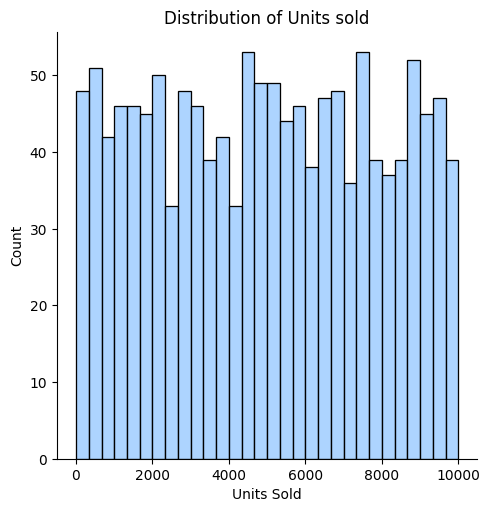

In [ ]:
# checking for abnormal values ​​for Units Sold column
sns.displot(data=events, x='Units Sold', bins=30)
plt.title("Distribution of Units sold")
plt.show()

The Units Sold data has a uniform distribution, no anomalies have been detected.

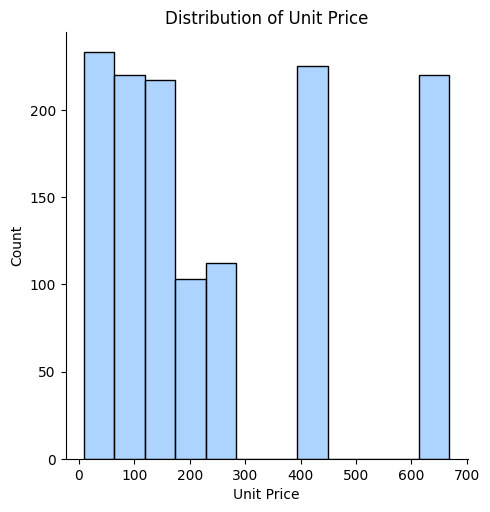

In [ ]:
# checking for abnormal values ​​for Units Sold column
sns.displot(data=events, x='Unit Price')
plt.title("Distribution of Unit Price")
plt.show()

The price distribution is multimodal with pronounced gaps, indicating the presence of several distinct price categories of goods.

### Countries table cleaning

In [ ]:
countries.isna().sum()

,0
name,0
alpha-2,1
alpha-3,0
region,1
sub-region,1


In [ ]:
#checking rows with missing values
countries[countries['alpha-2'].isna()]

,name,alpha-2,alpha-3,region,sub-region
153,Namibia,NaN,NAM,Africa,Sub-Saharan Africa


The system incorrectly identified the Namibia country code "NA" as an empty value. Therefore, we'll fill this value with the correct "NA" value:

In [ ]:
countries['alpha-2'] = countries['alpha-2'].fillna('NA')

In [ ]:
#checking rows with missing values
countries[countries['region'].isna()]

,name,alpha-2,alpha-3,region,sub-region
8,Antarctica,AQ,ATA,NaN,NaN


There is no region for Antarctica, as there should be. But we need to fill these NaN values so that there are no errors during further analysis:

In [ ]:
countries = countries.fillna('Antarctica')

In [ ]:
# final check
countries.isna().sum()

,0
name,0
alpha-2,0
alpha-3,0
region,0
sub-region,0


In [ ]:
#checking data for duplicates
countries.duplicated().sum()

np.int64(0)

There are no duplicates in the countries table.

## **Data analysis and visualization**

In [ ]:
#bringing column names to a single standard
events.columns = ['order_id', 'order_date', 'ship_date', 'order_priority', 'country_code', 'product_id', 'sales_channel', 'units_sold', 'unit_price', 'unit_cost']
events.columns

Index(['order_id', 'order_date', 'ship_date', 'order_priority', 'country_code',
       'product_id', 'sales_channel', 'units_sold', 'unit_price', 'unit_cost'],
      dtype='object')

In [ ]:
#bringing column names to a single standard
countries.columns = ['country_name', 'alpha_2', 'country_code', 'region', 'sub_region']
countries.columns

Index(['country_name', 'alpha_2', 'country_code', 'region', 'sub_region'], dtype='object')

In [ ]:
#bringing column names to a single standard
products.columns = ['product_id', 'item_type']
products.columns

Index(['product_id', 'item_type'], dtype='object')

In [ ]:
#joining 3 tables
df = (
    events
    .merge(products, how='left', on='product_id')
    .merge(countries, how='left', on='country_code')
)

In [ ]:
df.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,item_type,country_name,alpha_2,region,sub_region
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,Cereal,Norway,NO,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,Cereal,Serbia,RS,Europe,Southern Europe
2,101025998,2014-07-18,2014-08-11,M,Unknown,7940,Online,4693.0,668.27,502.54,Household,NaN,NaN,NaN,NaN
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,Clothes,Montenegro,ME,Europe,Southern Europe
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,Beverages,Serbia,RS,Europe,Southern Europe


In [ ]:
#removing unnecessary column
df = df.drop('alpha_2', axis=1)

In [ ]:
# filling missing country values
df = df.fillna('Unknown')

In [ ]:
df.isna().sum()

,0
order_id,0
order_date,0
ship_date,0
order_priority,0
country_code,0
product_id,0
sales_channel,0
units_sold,0
unit_price,0
unit_cost,0


In [ ]:
# creating new columns
df['delivery_time'] = (df['ship_date'] - df['order_date']).dt.days
df['month'] = df["order_date"].dt.month
df['weekday'] = df['order_date'].dt.day_name()
df['revenue'] = df['unit_price'] * df['units_sold']
df['total_cost'] = df['units_sold'] * df['unit_cost']
df['profit'] = df['revenue'] - df['total_cost']
df['year'] = df['order_date'].dt.year

In [ ]:
df.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,...,country_name,region,sub_region,delivery_time,month,weekday,revenue,total_cost,profit,year
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,...,Norway,Europe,Northern Europe,10,10,Wednesday,133705.00,76121.50,57583.50,2014
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,...,Serbia,Europe,Southern Europe,0,8,Thursday,409960.10,233400.23,176559.87,2016
2,101025998,2014-07-18,2014-08-11,M,Unknown,7940,Online,4693.0,668.27,502.54,...,Unknown,Unknown,Unknown,24,7,Friday,3136191.11,2358420.22,777770.89,2014
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,...,Montenegro,Europe,Southern Europe,31,5,Saturday,127966.88,41968.64,85998.24,2017
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,...,Serbia,Europe,Southern Europe,38,8,Saturday,362897.60,243129.92,119767.68,2012


In [ ]:
df['sales_channel'] = df['sales_channel'].str.title()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        1330 non-null   int64         
 1   order_date      1330 non-null   datetime64[ns]
 2   ship_date       1330 non-null   datetime64[ns]
 3   order_priority  1330 non-null   object        
 4   country_code    1330 non-null   object        
 5   product_id      1330 non-null   int64         
 6   sales_channel   1330 non-null   object        
 7   units_sold      1330 non-null   float64       
 8   unit_price      1330 non-null   float64       
 9   unit_cost       1330 non-null   float64       
 10  item_type       1330 non-null   object        
 11  country_name    1330 non-null   object        
 12  region          1330 non-null   object        
 13  sub_region      1330 non-null   object        
 14  delivery_time   1330 non-null   int64         
 15  mont

### Key performance metrics

In [ ]:
number_of_orders = df.shape[0]
print(f'Total number of orders:\n{number_of_orders}')

total_profit = df['profit'].sum()
print(f'\nTotal profit:\n{total_profit/1e6:.2f} millions')

n_countries = df['country_name'].nunique() - 1
print(f'\nNumber of countries:\n{n_countries}')

Total number of orders:
1330

Total profit:
501.84 millions

Number of countries:
45


### Sales analysis

#### Analysis by product categoties

Product categories by number of units sold:

In [ ]:
product_sold = df.groupby('item_type')['units_sold'].sum().sort_values(ascending=False).reset_index()
product_sold

,item_type,units_sold
0,Office Supplies,617641.0
1,Beverages,613133.0
2,Fruits,591672.0
3,Clothes,591385.0
4,Vegetables,582544.0
5,Baby Food,562706.0
6,Personal Care,562640.0
7,Meat,535342.0
8,Cosmetics,533291.0
9,Snacks,490160.0


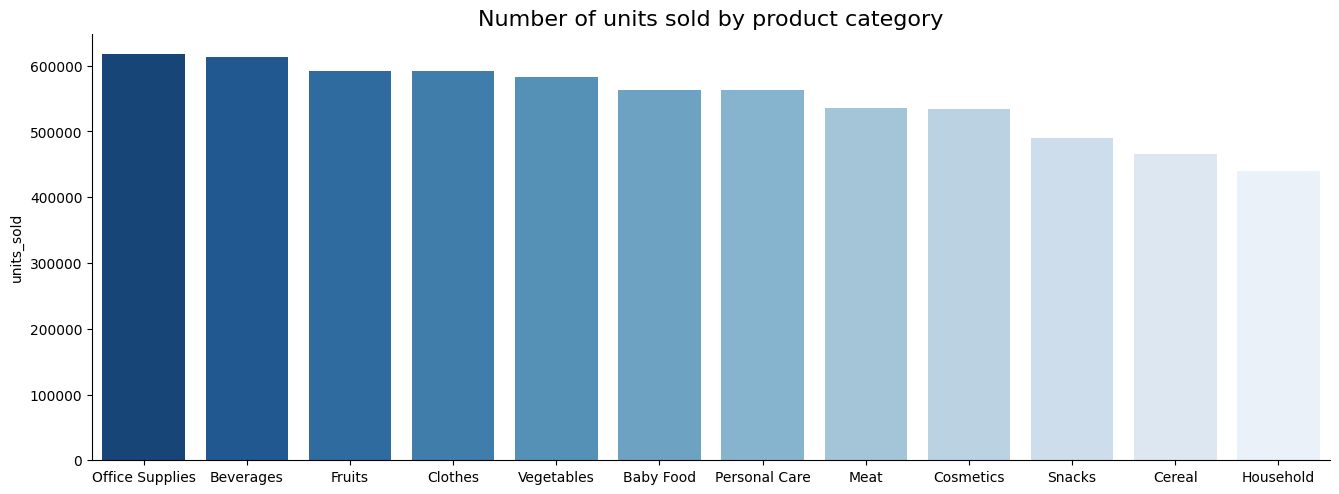

In [ ]:
sns.catplot(data=product_sold, x='item_type', y='units_sold', kind = 'bar', aspect=2.7, hue = 'item_type', palette='Blues_r')
plt.title('Number of units sold by product category', fontsize=16)
plt.xlabel(None)
plt.show()

The leaders in terms of units sold are Office Supplies and Beverages (over 610 thousand), while the smallest volume of sales is in the Household category. Overall, the difference between the most popular and least popular product is about 30%, which indicates fairly even demand across all segments.

Product categories by profit:

In [ ]:
product_profit = df.groupby('item_type')['profit'].sum().sort_values(ascending=False).reset_index()
product_profit

,item_type,profit
0,Cosmetics,92723306.17
1,Office Supplies,77977176.25
2,Household,72962466.77
3,Baby Food,53940997.16
4,Clothes,43431314.40
5,Cereal,41255034.15
6,Vegetables,36776002.72
7,Meat,30621562.40
8,Snacks,27027422.40
9,Personal Care,14099758.40


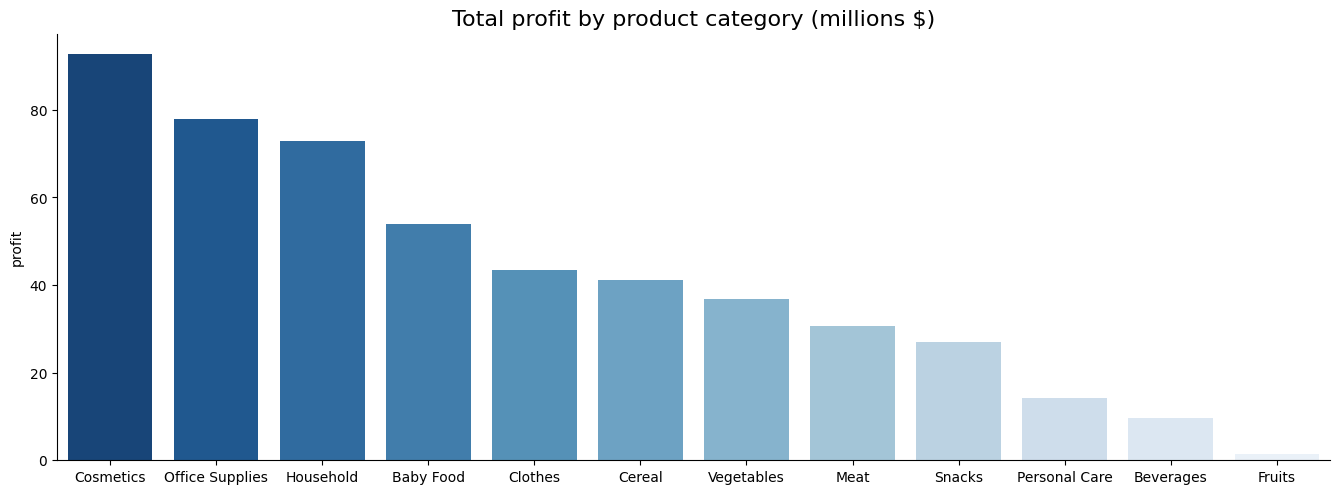

In [ ]:
sns.catplot(data=product_profit, x='item_type', y=product_profit['profit']/1e6, kind = 'bar', aspect=2.7, hue = 'item_type', palette='Blues_r')
plt.title('Total profit by product category (millions $)', fontsize=16)
plt.xlabel(None)
plt.show()

The most profitable category is Cosmetics (~92.7 million), which together with Office Supplies and Household forms the bulk of the company's revenue. In contrast, food categories such as Fruits and Beverages have the lowest margins.

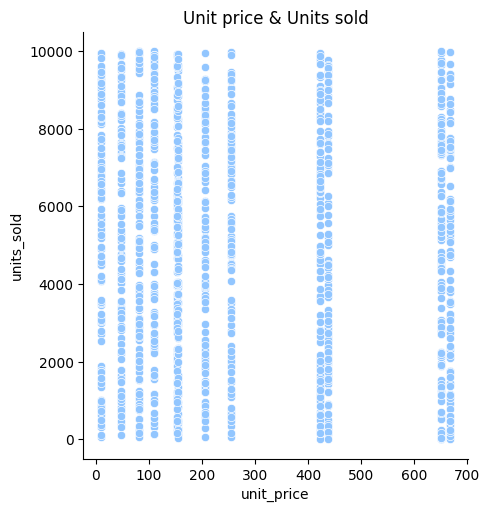

In [ ]:
sns.relplot(data=df, x='unit_price', y='units_sold')
plt.title('Unit price & Units sold')
plt.show()

Analysis of sales volumes versus price showed that products have fixed price levels. However, no direct relationship was found between the unit price and the quantity of goods sold: expensive items are sold as actively as budget items.

#### Analysis by geography

Top-10 countries by profit:

In [ ]:
#filtering unknown countries
country_data = df[~ (df['country_name'] == 'Unknown')]

top_countries = country_data.groupby('country_name')['profit'].sum().sort_values(ascending=False).reset_index().head(10)
top_countries

,country_name,profit
0,Andorra,15410036.63
1,Ukraine,14804925.74
2,Malta,14610127.88
3,San Marino,13792992.81
4,Hungary,13786231.03
5,Macedonia,13684099.95
6,Czech Republic,13635593.78
7,Russia,13267682.64
8,Bosnia and Herzegovina,13257602.77
9,Greece,12324450.13


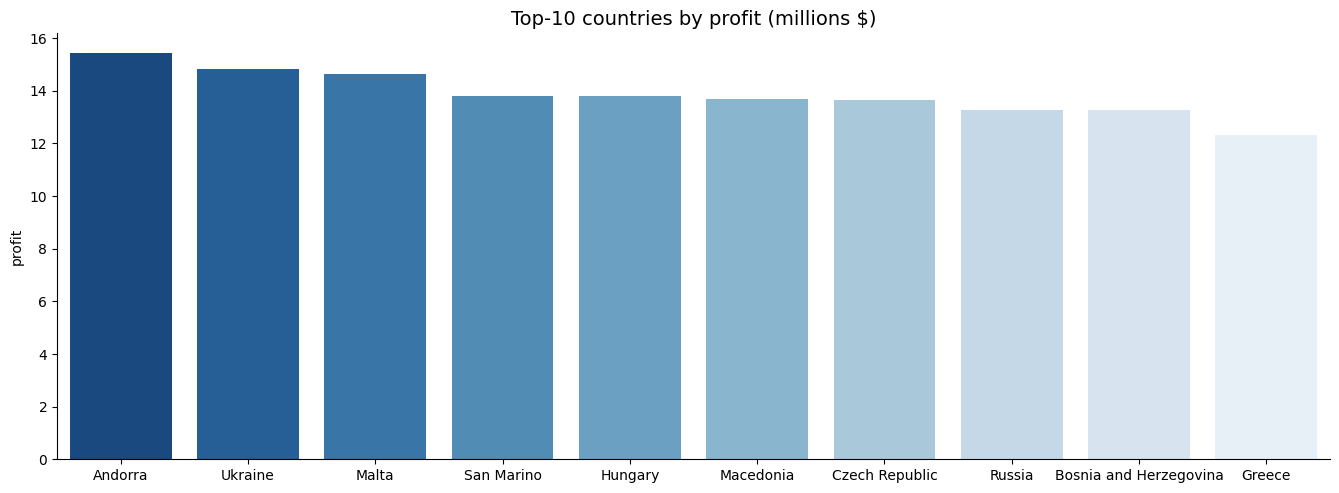

In [ ]:
sns.catplot(data=top_countries, x='country_name', y=top_countries['profit']/1e6, kind = 'bar', aspect=2.7, hue = 'country_name', palette='Blues_r')
plt.title('Top-10 countries by profit (millions $)', fontsize=14)
plt.xlabel(None)
plt.show()

The most profitable market is Andorra (~15.4 million), followed by Ukraine and Malta with a small margin. All top ten countries in the ranking represent the European region.

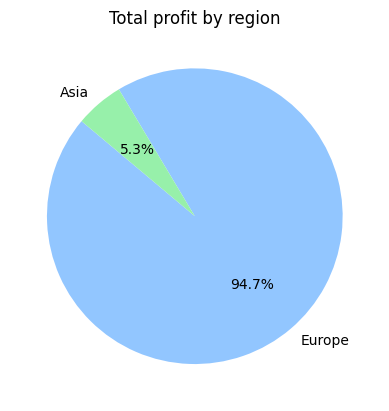

In [ ]:
region_profit = country_data.groupby('region')['profit'].sum().sort_values(ascending=False)
plt.pie(
    region_profit,
    labels=region_profit.index,
    autopct='%1.1f%%',
    startangle=140
)
plt.title('Total profit by region')
plt.show()

Europe is the dominant region, providing the vast majority of revenue — 94.7%. Asia's contribution to the overall revenue structure is minimal, at only 5.3%.

In [ ]:
#subregions grouping
sub_regions = country_data.groupby(['sub_region', 'sales_channel'])['profit'].sum().sort_values(ascending=False).reset_index()
sub_regions['profit'] = sub_regions['profit'] / 1_000_000
sub_regions.columns = ['Subregion', 'Sales Channel', 'Profit (M)']

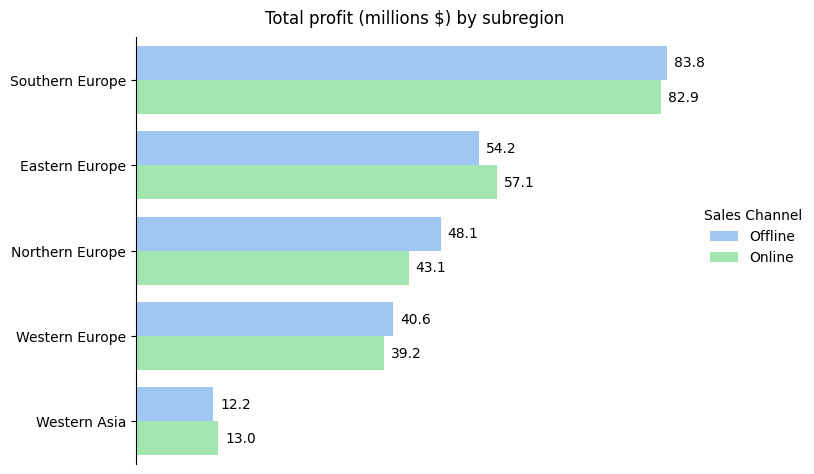

In [ ]:
# subregion profit visualising
g = sns.catplot(data=sub_regions, x='Profit (M)', y='Subregion', kind='bar', hue='Sales Channel', estimator=np.sum, errorbar=None, aspect=1.5)
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f', padding=5, fontsize=10)
    ax.get_xaxis().set_visible(False)
    sns.despine(left=False, bottom=True)
plt.title('Total profit (millions $) by subregion', pad=10)
plt.ylabel(None)
plt.show()

Southern Europe is the absolute leader in terms of profit, demonstrating high figures (over $80 million) in both sales channels. The lowest level of profit was recorded in Western Asia. In most European regions (Southern, Northern and Western Europe), the offline sales channel prevails.

#### Analysis by sales channel

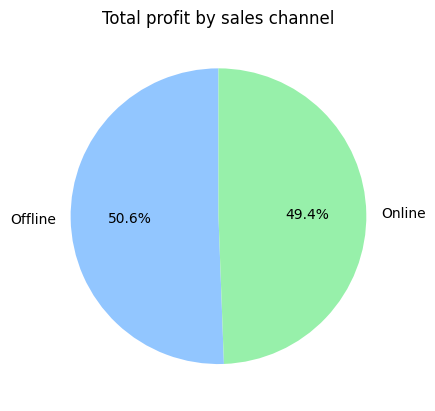

In [ ]:
channel_profit = df.groupby('sales_channel')['profit'].sum()
plt.pie(
    channel_profit,
    labels=channel_profit.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Total profit by sales channel')
plt.show()

Sales channels are evenly distributed — Offline (50.6%) and Online (49.4%) generate almost the same amount of profit.

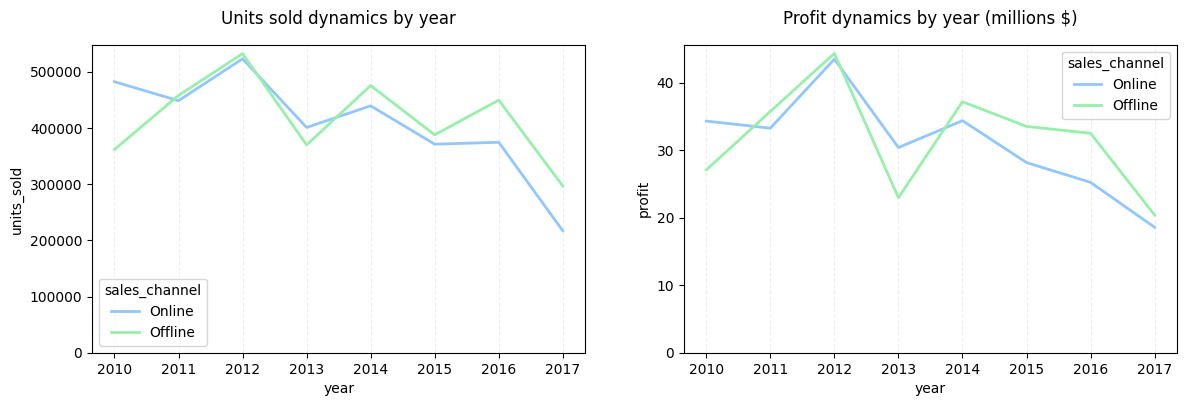

In [ ]:
#creating figures
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.lineplot(data=df, x='year', y='units_sold', hue='sales_channel', estimator=np.sum, errorbar=None, linewidth=2, ax=axes[0], )
axes[0].set_title('Units sold dynamics by year', pad=15)
axes[0].grid(axis='x', linestyle='--', alpha=0.2)
axes[0].set_ylim(bottom=0)

sns.lineplot(data=df, x='year', y=df['profit']/1e6, hue='sales_channel', estimator=np.sum, errorbar=None, linewidth=2, ax=axes[1])
axes[1].set_title('Profit dynamics by year (millions $)', pad=15)
axes[1].grid(axis='x', linestyle='--', alpha=0.2)
axes[1].set_ylim(bottom=0)

plt.show()

Both graphs show similar dynamics for both sales channels from 2010 to 2017, indicating a direct dependence of profit on sales volumes. The highest figures for both unit sales and profit were recorded in 2012. During the period, offline sales largely outpaced the online channel, maintaining leadership in terms of volume and revenue. The overall dynamics are negative.

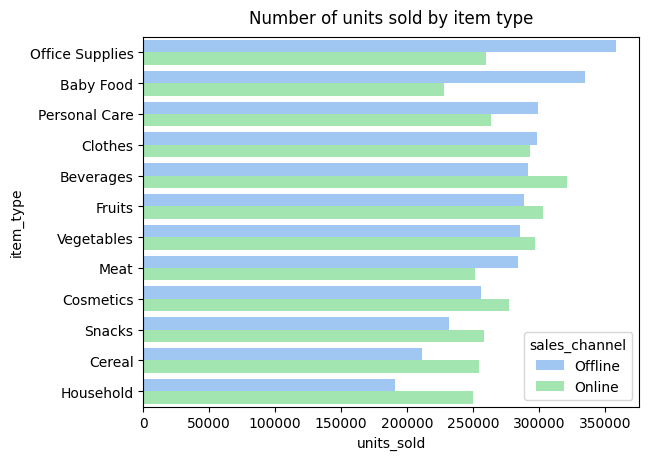

In [ ]:
#grouping by item type and sales channel
product_channel = df.groupby(['item_type', 'sales_channel'])['units_sold'].sum().reset_index()

#setting order of item type
sorted = product_channel[product_channel['sales_channel'] == 'Offline'].sort_values(by='units_sold', ascending=False).set_index('item_type').index

#creating barchart
sns.barplot(data=product_channel, y='item_type', x='units_sold', hue='sales_channel', order=sorted)
plt.title('Number of units sold by item type', pad=10)
plt.show()

In categories such as Office Supplies, Baby Food, Meat and Personal Care, offline sales significantly outperform online. Beverages, Fruits and Cosmetics are better sold online. In the Clothes category, sales through both channels are almost identical.

### Order delivery time analysis

Delivery time statistics by item type:

In [ ]:
delivery_stats_items = df.groupby('item_type')['delivery_time'].agg(['mean', 'median', 'max']).sort_values(by='mean').reset_index().round(2)
delivery_stats_items

,item_type,mean,median,max
0,Personal Care,20.72,20.0,50
1,Clothes,23.10,21.0,50
2,Vegetables,23.49,21.0,50
3,Household,23.94,24.0,50
4,Beverages,24.12,23.0,50
5,Fruits,24.42,23.0,50
6,Snacks,25.54,25.0,49
7,Meat,25.85,25.0,50
8,Cosmetics,25.91,28.0,50
9,Baby Food,26.34,28.5,50


The average delivery time for most categories ranges from 21 to 26 days. Since the median and mean are quite close to each other, this indicates a relatively even process without massive small deviations.

The fastest orders are processed for Personal Care (average 20.7 days). The slowest category is Cereal, where the average wait time is over 27 days.

Delivery time statistics by country:

In [ ]:
# top-10 countries with the smallest average delivery time
delivery_stats_country_min = df.groupby('country_name')['delivery_time'].agg(['mean', 'median', 'max']).sort_values(by='mean').reset_index().round(2).nsmallest(10, 'mean')
delivery_stats_country_min

,country_name,mean,median,max
0,Croatia,18.22,12.5,45
1,United Kingdom,18.39,19.0,46
2,Denmark,19.69,21.0,49
3,Estonia,20.52,17.0,49
4,Serbia,20.59,18.0,50
5,Latvia,20.89,21.0,45
6,Malta,21.56,23.0,48
7,San Marino,21.70,20.5,49
8,Liechtenstein,22.96,18.5,50
9,Greece,23.00,23.5,48


In [ ]:
# top-10 countries with the largest average delivery time
delivery_stats_country_max = df.groupby('country_name')['delivery_time'].agg(['mean', 'median', 'max']).sort_values(by='mean').reset_index().round(2).nlargest(10, 'mean')
delivery_stats_country_max

,country_name,mean,median,max
45,Hungary,32.64,36.0,50
44,Georgia,29.70,32.0,47
43,Austria,28.50,29.0,50
42,Slovakia,28.47,32.0,50
41,Luxembourg,27.75,30.5,48
40,Lithuania,27.56,30.0,49
39,Poland,27.46,27.0,50
38,Russia,27.38,34.0,50
37,Monaco,26.85,33.0,48
36,Bulgaria,26.80,26.0,48


Delivery time statistics by region:

In [ ]:
delivery_stats_region = country_data.groupby('sub_region')['delivery_time'].agg(['mean', 'median', 'max']).sort_values(by='mean').reset_index().round(2)
delivery_stats_region

,sub_region,mean,median,max
0,Northern Europe,23.02,21.0,50
1,Southern Europe,23.85,23.0,50
2,Western Europe,25.88,26.0,50
3,Western Asia,26.09,25.5,50
4,Eastern Europe,26.96,29.0,50


The shortest delivery time is in Northern Europe - an average of 23 days, while the longest is in Eastern Europe - around 27 days.

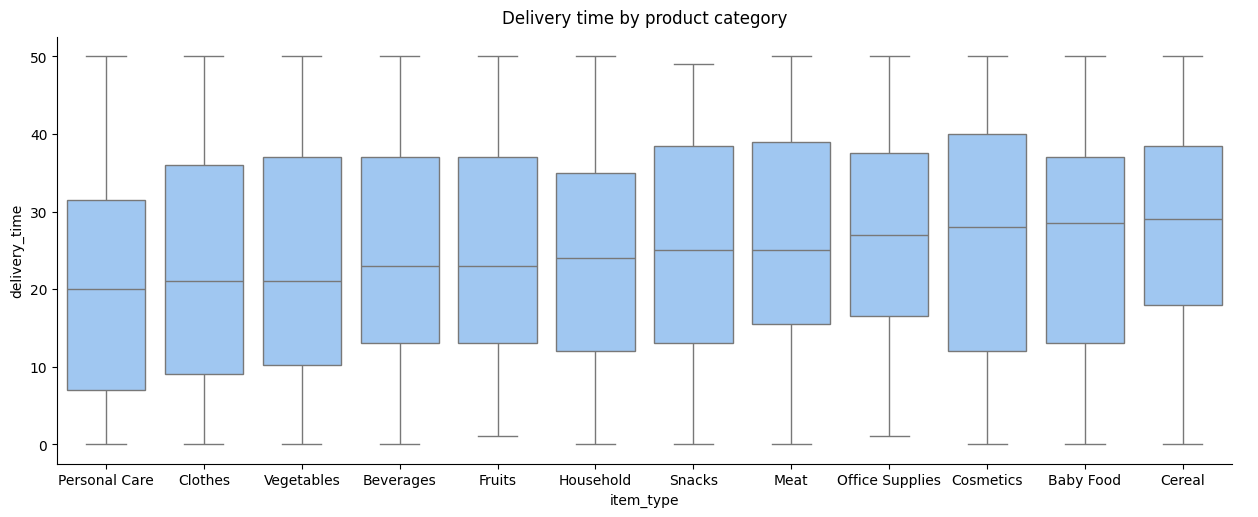

In [ ]:
#sorting product categories by median
items_sorted = delivery_stats_items.sort_values(by='median').set_index('item_type').index

sns.catplot(data=df, x='item_type', y='delivery_time', kind='box', aspect=2.5, order=items_sorted)
plt.title('Delivery time by product category', pad=10)
plt.show()

The median delivery time for most categories is relatively stable, fluctuating between 20 and 30 units. The Personal Care category has the lowest median and is generally biased towards lower delivery times compared to the others. The Cereal and Baby Food categories show some of the highest median delivery times.

All categories have a significant range of values, from 0 to 50 units. This indicates that regardless of the type of product, delivery times can vary significantly from case to case.

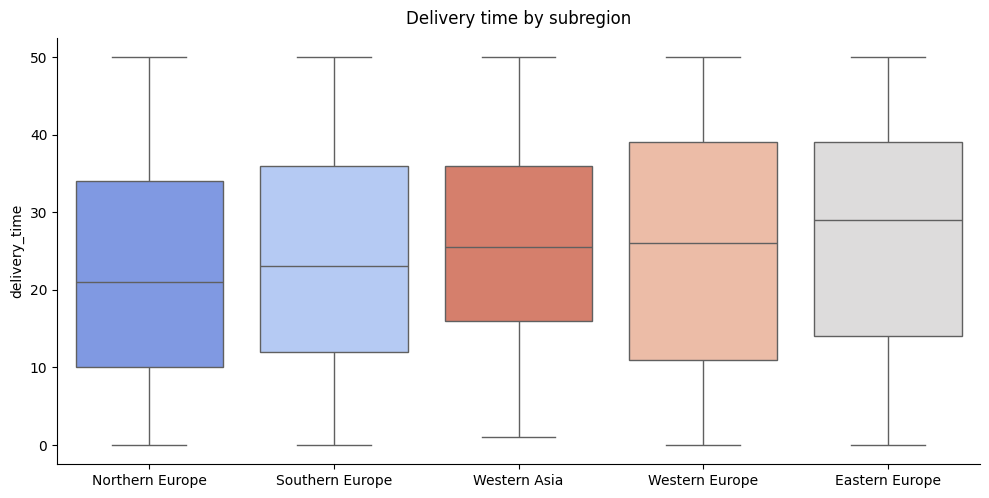

In [ ]:
#sorting regions by median
regions_sorted = delivery_stats_region.sort_values(by='median').set_index('sub_region').index

sns.catplot(data=country_data, x='sub_region', y='delivery_time', kind='box', aspect=2, order=regions_sorted, hue='sub_region', palette='coolwarm')
plt.title('Delivery time by subregion', pad=10)
plt.xlabel(None)
plt.show()

Northern Europe shows the best results with the lowest median delivery time (around 21 days).
Eastern Europe has the highest median delivery time (around 29 days). This indicates that on average, delivery in this region takes longer than in the other sub-regions represented.

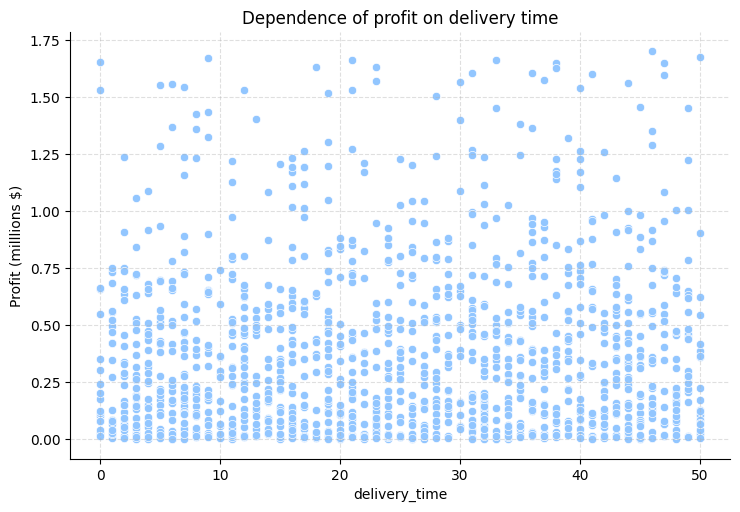

In [ ]:
sns.relplot(data=df, x='delivery_time', y=df['profit']/1e6, kind='scatter', aspect=1.5)
plt.title('Dependence of profit on delivery time')
plt.ylabel('Profit (milllions $)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

There is no clear relationship between delivery time and profit. The points are distributed across the entire plane of the graph without a pronounced trend (upward or downward). This means that increasing the shipping time does not automatically lead to a decrease or increase in profit.

### Analysis of dynamics

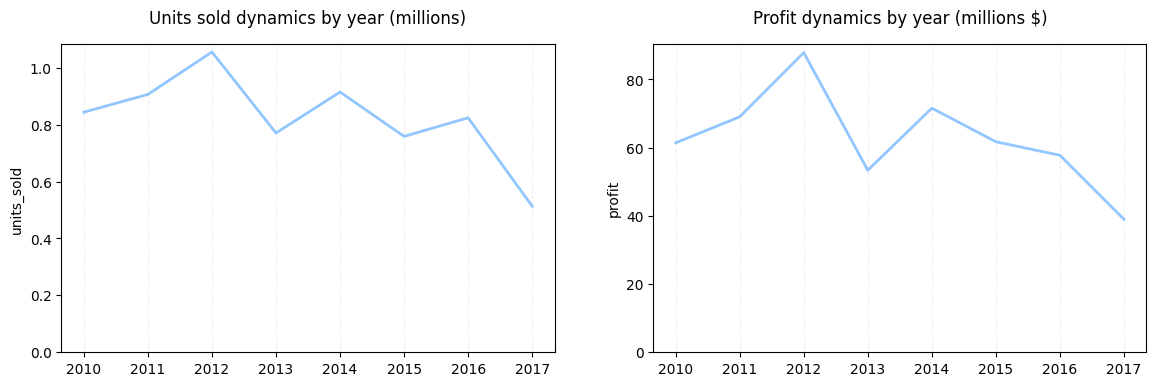

In [ ]:
dynamic = df.groupby('year')[['units_sold', 'profit']].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.lineplot(data=dynamic, x='year', y=dynamic['units_sold']/1e6, errorbar=None, linewidth=2, ax=axes[0])
axes[0].set_title('Units sold dynamics by year (millions)', pad=15)
axes[0].grid(axis='x', linestyle='--', alpha=0.2)
axes[0].set_(bottom=0)
axes[0].set_xlabel(None)

sns.lineplot(data=dynamic, x='year', y=dynamic['profit']/1e6, errorbar=None, linewidth=2, ax=axes[1])
axes[1].set_title('Profit dynamics by year (millions $)', pad=15)
axes[1].grid(axis='x', linestyle='--', alpha=0.2)
axes[1].set_ylim(bottom=0)
axes[1].set_xlabel(None)

plt.show()

2012 was the most successful year of the entire observation period: sales exceeded 1 million units, and profits peaked at almost $90 million.

A sharp decline occurred in 2013, after which a partial recovery occurred in 2014. During 2015–2016, a gradual decline in indicators was observed.

The graphs show a sharp decline in 2017. However, since the data is indicated only through July, this “collapse” is fictitious. In 7 months, the company has already sold more than 0.5 million units of goods and received about $40 million in profit. If we extrapolate these data to the entire year, the 2017 indicators will probably be on par with or even slightly higher than the 2016 indicators.

In [ ]:
#calculation of percentage change (2016 & 2010)
change = df.pivot_table(values = 'units_sold', index='item_type', columns='year', aggfunc='sum').reset_index()
change['%_change'] = (change[2016] - change[2010]) / change[2010] * 100
change = change.sort_values(by='%_change', ascending=False)

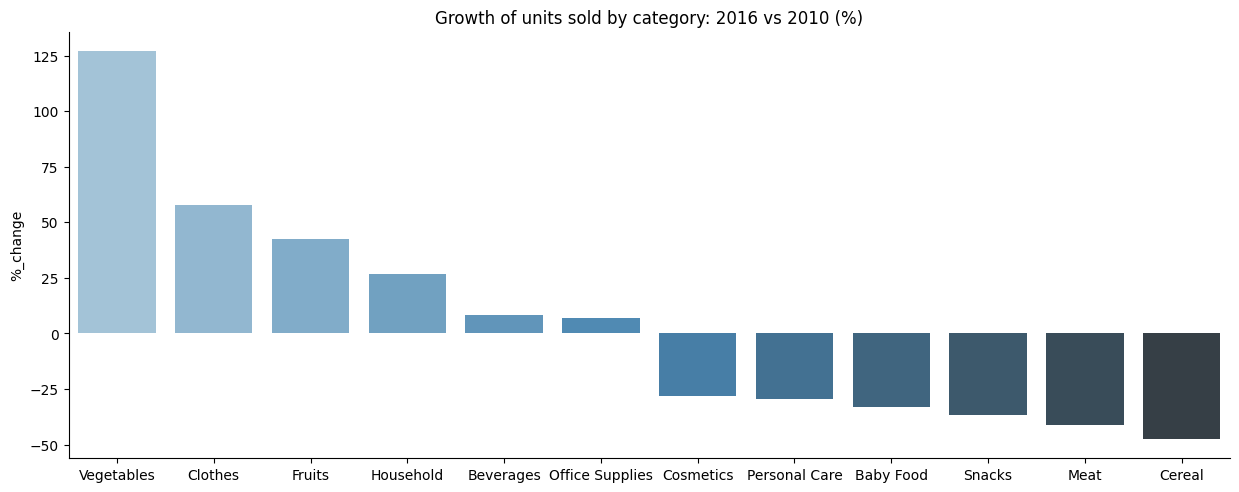

In [ ]:
sns.catplot(data=change, x='item_type', y='%_change', kind = 'bar', hue='item_type', palette='Blues_d', aspect=2.5)
plt.title('Growth of units sold by category: 2016 vs 2010 (%)')
plt.xlabel(None)
plt.show()

The graph demonstrates a significant polarity in the dynamics of sales between different product categories for the period 2010–2016. The undisputed leader in growth is the Vegetables category, whose sales volumes increased by more than 125%, which indicates a rapid increase in demand for these products. Also, positive dynamics (from 10% to 60%) are maintained by clothing, fruits, household goods and office supplies.

At the same time, the group of products that includes cosmetics, baby food, snacks and meat is showing regression. The largest drop was recorded in the Cereal category, where sales volumes decreased by almost 50%.

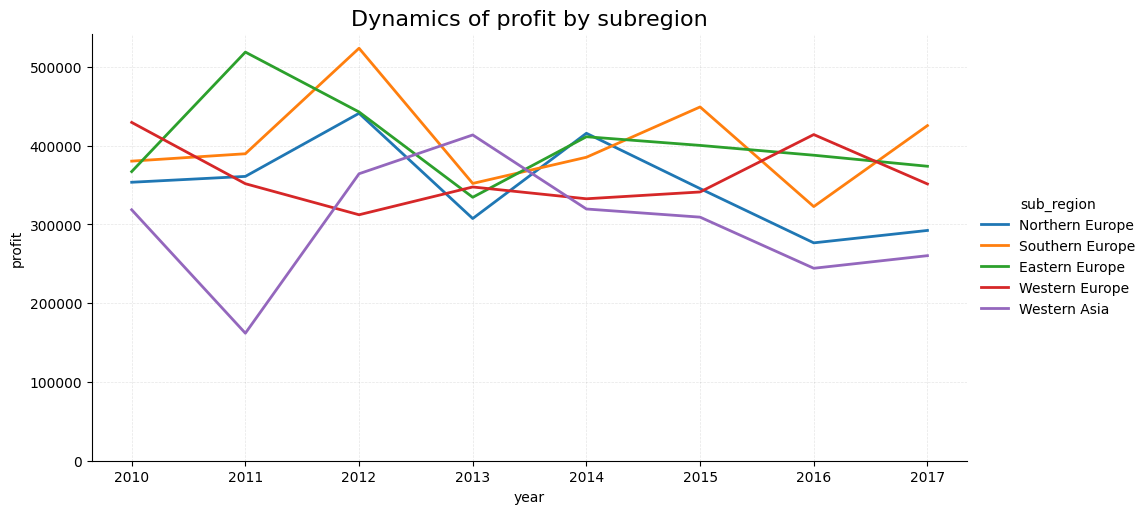

In [ ]:
sns.relplot(data=country_data, x='year', y='profit', kind='line',errorbar=None, hue='sub_region', linewidth=2, aspect=2, palette='tab10')
plt.title('Dynamics of profit by subregion', y=1.001, fontsize=16)
plt.grid(linestyle='--', alpha=0.1, color='black', linewidth=0.5)
plt.ylim(0)
plt.show()

Each sub-region has a unique profit trajectory, and there is no global unified trend. The most stable and upward trend in recent years is shown by Southern Europe, where after the decline in 2013, a confident recovery is observed, and the indicators for 2017 (despite the fact that data is available for only 7 months) are already approaching the peak values ​​​​of previous years. In contrast, Western Asia is the most worrying: after a rapid take-off in 2013, the region shows a steady annual decline in profits, which may indicate a loss of market share or changing economic conditions in this segment.

In [ ]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

weekday_pivot = df.pivot_table(index='item_type',
                               columns='weekday',
                               values='units_sold',
                               aggfunc='sum').reindex(columns=day_order)

weekday_pivot

weekday,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
item_type,,,,,,,
Baby Food,61113.0,85446.0,81235.0,73737.0,79129.0,88333.0,93713.0
Beverages,102123.0,80268.0,75604.0,85538.0,67500.0,102630.0,99470.0
Cereal,41674.0,58098.0,58217.0,58274.0,62637.0,96269.0,90516.0
Clothes,68109.0,124242.0,43538.0,88375.0,61274.0,100874.0,104973.0
Cosmetics,55888.0,81409.0,68610.0,70649.0,141526.0,65086.0,50123.0
Fruits,118092.0,42790.0,85792.0,56175.0,43936.0,109137.0,135750.0
Household,107829.0,20474.0,95560.0,46726.0,65189.0,56825.0,47646.0
Meat,100388.0,91458.0,89231.0,65817.0,53575.0,79330.0,55543.0
Office Supplies,93941.0,76473.0,93604.0,80415.0,105888.0,64971.0,102349.0


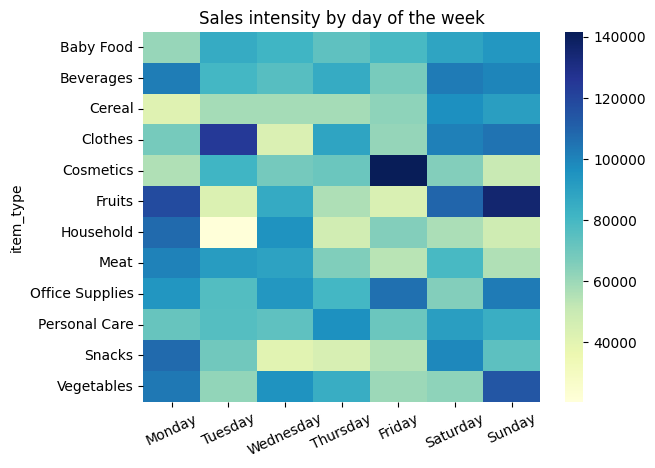

In [ ]:
# plt.figure(figsize=(12, 8))
sns.heatmap(weekday_pivot, annot=False, cmap='YlGnBu')
plt.title('Sales intensity by day of the week')
plt.xlabel(None)
plt.xticks(rotation=25)
plt.show()

Cosmetics has an absolute peak on Friday. This is the most pronounced pattern on the entire chart.

Fruits and Vegetables show similar dynamics with peaks on Monday and Sunday. This indicates that consumers tend to purchase fresh produce either at the beginning of the workweek or during large purchases on the weekend.

Clothes has an interesting anomaly — peaks occur on Tuesdays and weekends. The high figure on Tuesdays may be specific to a particular region or the schedule of assortment/discount updates.

The Personal Care and Baby Food categories have the most even distribution of purchases. Although there is a slight increase on weekends, demand for them remains stable throughout the week, which is logical for essential goods.

Office Supplies has increased intensity on Friday and Sunday.

## General conclusions and recommendations

Based on the results of the analysis of 1,330 orders in 45 countries for the period 2010–2017, the following conclusions and strategic recommendations for business can be formulated:

1. **Focus on high-margin products**

The Cosmetics, Office Supplies and Household categories are the main drivers of the company's profit.

Although Cosmetics is inferior to beverages in terms of unit sales, its higher price per unit and margin make this category a priority for revenue.

***Recommendation:***   
expand the range in the Cosmetics and Household categories, and focus marketing efforts on promoting these products, as they bring the highest return on each unit sold.    

---

2. **Optimize low-margin categories**

The Fruits and Beverages categories show high sales volumes (leaders in unit volume), but bring the lowest profit. This indicates that these categories have low margins. High logistics and storage costs for such products can absorb most of the revenue.

***Recommendation:***   
audit operating expenses for these categories. If they do not work as “product magnets” to attract traffic, it is worth considering raising prices or renegotiating contracts with suppliers to increase margins.

---

3. **Geographical concentration**

Europe is a key market, providing 94.7% of the company's total profit. Top markets are Andorra, Ukraine and Malta.

Such excessive concentration on one region makes the business vulnerable to local economic or geopolitical fluctuations in Europe.

***Recommendation:***   
Continue to develop the European direction, but at the same time develop a strategy to enter the markets of Asia or other regions to diversify the risk portfolio.

---

4. **Responding to Negative Trends**

The West Asia region has seen a steady trend of declining profits since 2013. A consistent annual decline could indicate a loss of market share or a change in consumer preferences.

***Recommendation:***   
conduct an in-depth study of the reasons for the decline in West Asia. A decision needs to be made: either change the sales strategy in this region or reallocate resources to more promising markets in Europe.